In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
df = pd.read_csv('C:/Users/Admin/Downloads/transactions_.csv')
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,net_change_org,net_change_dest,ratio_amount_orig,ratio_amount_dest,orig_zero_after,dest_zero_after
0,8,158007,0,0,474016,1618631,0,0,1144615,15800711999,0,1,0
1,236,457948,0,0,2720411,3178359,0,0,457948,45794829999,0,1,0
2,37,153602,11160428,11314031,3274930,3121327,0,153603,-153603,0,0,0,0
3,331,49555,10865,0,0,49555,0,-10865,49555,4,4955514000,1,0
4,250,29648,0,0,56933,86581,0,0,29648,2964802000,0,1,0


```
Choosing the optimal number of clusters in KMeans...

In [30]:
x = df.drop('isFraud', axis=1)
x_scaled = StandardScaler().fit_transform(x)

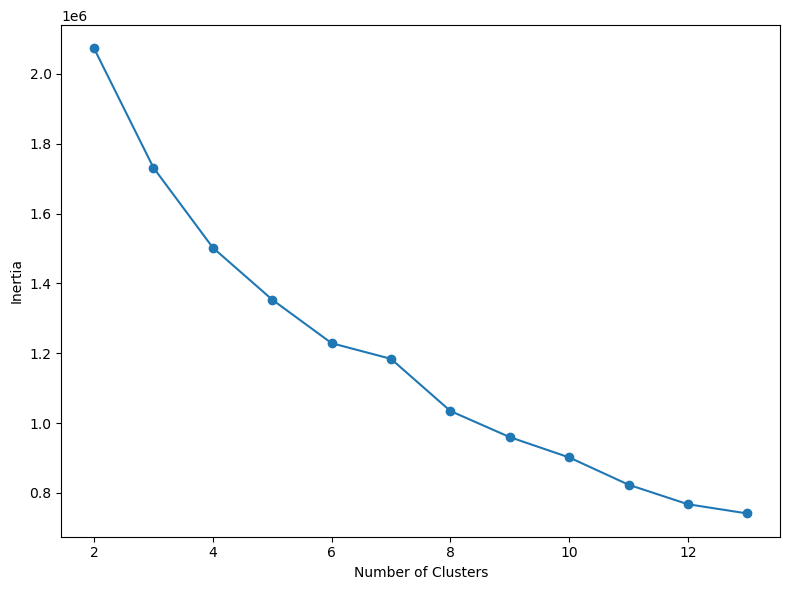

In [31]:
distance_values=[]
for cluster in range(2, 14):
    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=1)
    kmeans.fit_predict(x_scaled)
    distance_values.append(kmeans.inertia_)

cluster_output = pd.DataFrame({'Cluster': range(2, 14), 'distance_values': distance_values})

plt.figure(figsize=(8, 6))
plt.plot(cluster_output['Cluster'], cluster_output['distance_values'], marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

```
Clustering Dataset...

In [32]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=1)
label = kmeans.fit_predict(x_scaled)

df_temp = df.copy()
df_temp['label'] = label.astype(str)

df_temp['label'].value_counts()

label
3    76295
1    75814
0    36137
5     7272
4     4332
2      149
Name: count, dtype: int64

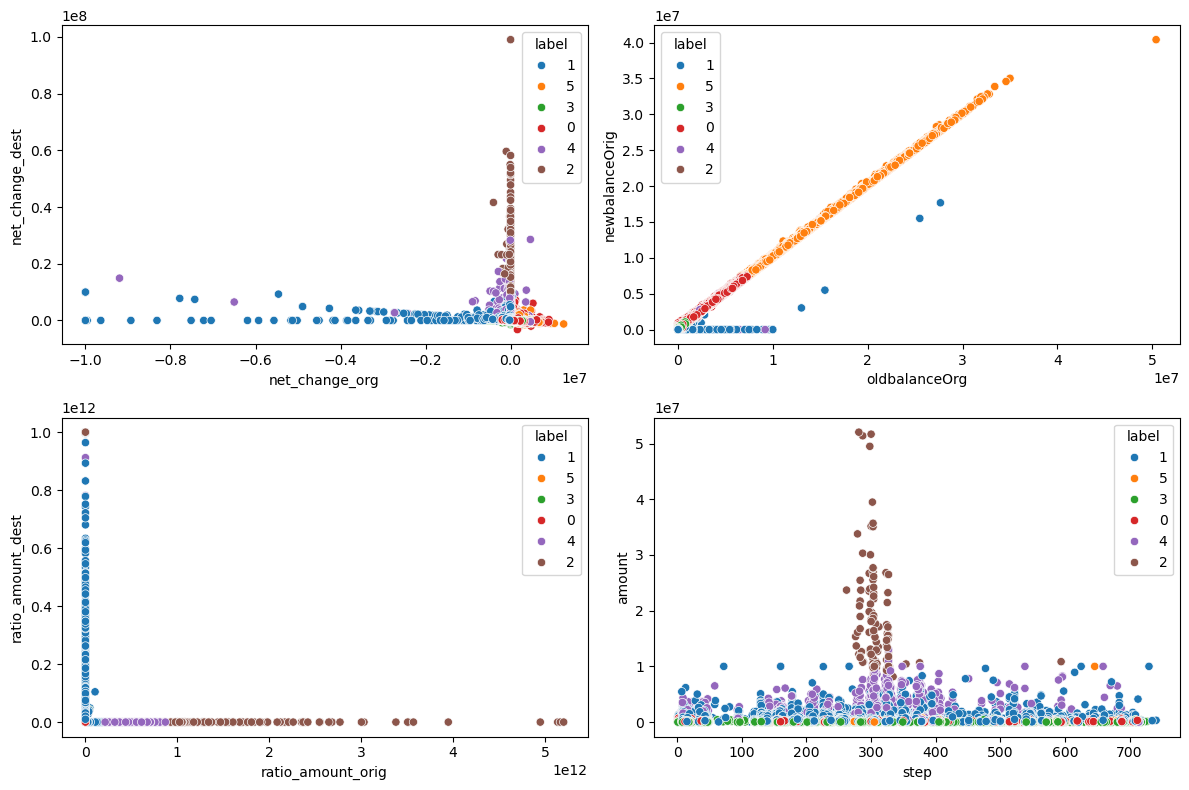

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax1 = sns.scatterplot(data=df_temp, x='net_change_org', y='net_change_dest', hue='label', ax=ax[0, 0])
ax1 = sns.scatterplot(data=df_temp, x='oldbalanceOrg', y='newbalanceOrig', hue='label', ax=ax[0, 1])
ax1 = sns.scatterplot(data=df_temp, x='ratio_amount_orig', y='ratio_amount_dest', hue='label', ax=ax[1, 0])
ax1 = sns.scatterplot(data=df_temp, x='step', y='amount', hue='label', ax=ax[1, 1])

plt.tight_layout()
plt.show()

```
Profiling Kmeans Clusters...

In [34]:
cols = df_temp.drop(columns=['isFraud', 'label']).columns.tolist()

overall_mean = df_temp[cols].apply(np.mean).T
overall_mean = pd.DataFrame(overall_mean, columns=['overall_average'])

cluster_mean = df_temp.groupby('label')[cols].mean().T
pd.concat([cluster_mean, overall_mean], axis=1)

,0,1,2,3,4,5,overall_average
step,2.458962e+02,2.403645e+02,3.080403e+02,2.443734e+02,2.692345e+02,2.326856e+02,2.432898e+02
amount,1.388403e+05,2.777679e+05,1.612195e+07,3.345742e+04,8.825324e+05,1.642354e+05,1.802420e+05
oldbalanceOrg,1.639622e+06,3.011999e+04,1.390181e+04,7.011712e+04,6.022074e+05,1.331015e+07,8.314360e+05
newbalanceOrig,1.747965e+06,2.514104e+03,0.000000e+00,8.505173e+04,6.127132e+05,1.347163e+07,8.523331e+05
oldbalanceDest,1.343620e+06,1.181138e+06,2.994965e+07,4.330262e+03,1.462156e+07,1.717963e+06,1.093644e+06
newbalanceDest,1.252513e+06,1.475123e+06,5.243007e+07,0.000000e+00,1.556740e+07,1.571629e+06,1.218886e+06
net_change_org,1.083427e+05,-2.760588e+04,-1.390181e+04,1.493496e+04,1.050578e+04,1.614758e+05,2.089722e+04
net_change_dest,-9.110695e+04,2.939849e+05,2.248042e+07,-4.330262e+03,9.458362e+05,-1.463341e+05,1.252420e+05
ratio_amount_orig,1.886194e+08,1.223958e+10,1.356634e+12,4.468849e+08,5.748337e+10,0.000000e+00,7.100031e+09
ratio_amount_dest,4.302757e+08,4.660046e+09,5.369128e+10,2.337719e+09,2.277674e+09,1.379807e+08,2.830375e+09


```
Implementing Principal Components (PCA)...

```
Choosing the number of PCs...

In [35]:
pca = PCA(n_components=6, random_state=1)
pca_x = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(pca_x, columns=['pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6'])
pca_df.head()

,pca1,pca2,pca3,pca4,pca5,pca6
0,0.805044,-0.590317,0.047897,-0.353125,-1.979036,0.100866
1,1.374107,-0.374381,-0.437438,-0.464156,-0.410734,0.583974
2,-0.096383,5.262036,0.962562,-0.590311,-1.234898,-0.669717
3,-0.162029,-0.647005,0.001928,-0.817195,0.129401,1.039942
4,-0.190985,-0.581900,-0.172267,-0.680182,-0.435097,0.885340


In [36]:
for i in range(0, len(pca.explained_variance_ratio_)):
    print('Component ', i, '', pca.explained_variance_ratio_[i])

Component  0  0.2848889304161303
Component  1  0.20118269817086168
Component  2  0.11808461652861696
Component  3  0.1003961131323535
Component  4  0.08439007835731835
Component  5  0.0792770151028532


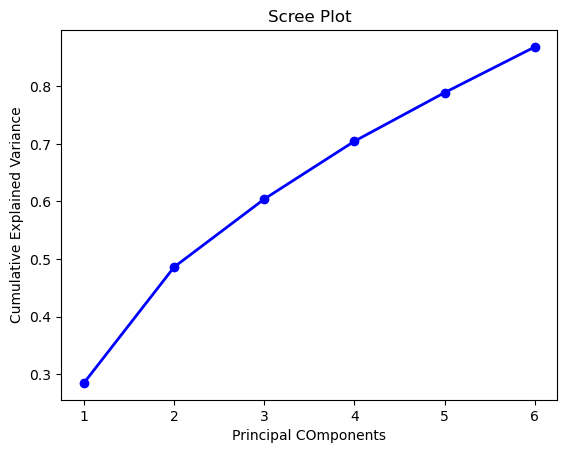

In [37]:
pc_values = np.arange(pca.n_components_) + 1
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(pc_values, cumulative_variance, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal COmponents')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [38]:
pca = PCA(n_components=6, random_state=1)
pca_x = pca.fit_transform(x_scaled)

loadings_df = pd.DataFrame(pca.components_).T
loadings_df = loadings_df.set_index(x.columns)

print(loadings_df)

print('\n\n###### Filter Out Below 0.35 #######\n')
print(loadings_df.where(abs(loadings_df) >= 0.35))

                          0         1         2         3         4         5
step               0.015644 -0.009787 -0.018848 -0.025573  0.884902  0.463509
amount             0.473205 -0.013203  0.278392  0.199172 -0.031167  0.086878
oldbalanceOrg     -0.028695  0.584550  0.269055 -0.122059 -0.015121  0.040835
newbalanceOrig    -0.032191  0.593525  0.250118 -0.098554 -0.019013  0.050370
oldbalanceDest     0.362770  0.174725 -0.450870 -0.213325  0.154170 -0.328223
newbalanceDest     0.435848  0.140848 -0.354955 -0.149846  0.126145 -0.280276
net_change_org    -0.074731  0.311265 -0.305621  0.428867 -0.079274  0.195096
net_change_dest    0.450130 -0.077879  0.237200  0.189439 -0.060749  0.079348
ratio_amount_orig  0.438404 -0.007644  0.110921  0.350710 -0.084953  0.185076
ratio_amount_dest  0.090462 -0.123096  0.532019 -0.326961  0.205733 -0.370670
orig_zero_after    0.128750 -0.318278 -0.072445 -0.406712 -0.235591  0.419967
dest_zero_after   -0.165068 -0.189553  0.087476  0.501970  0.246

```

PC0: high loadings on amount (0.473), newbalanceDest (0.436), ratio_amount_orig (0.438), net_change_dest (0.450) → PC0 mostly captures transaction size / destination impact.

PC1: high loadings on oldbalanceOrg (0.585), newbalanceOrig (0.594) → PC1 mostly captures sender balance.

PC2: high loading on ratio_amount_dest (0.532) → PC2 mostly captures destination ratio.

PC3: high loadings on dest_zero_after (0.502), net_change_org (0.429), orig_zero_after (-0.407) → PC3 captures zero-after / net change patterns.

PC4 & PC5: smaller contributions, could capture minor variance or interaction effects.

In [39]:
x = df.drop('isFraud', axis=1)
kmo_all, kmo_model = calculate_kmo(x)
kmo_model

np.float64(0.3937956046318917)

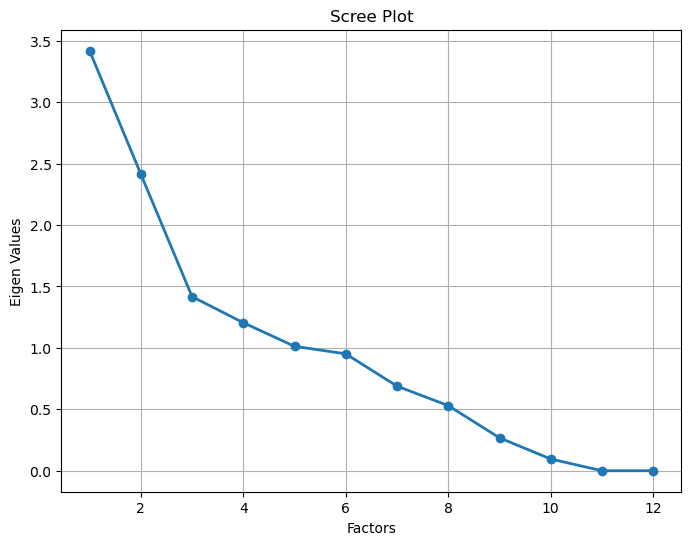

In [41]:
fa = FactorAnalyzer(rotation='varimax', n_factors=x.shape[1])
fa.fit(x)
ev,_ = fa.get_eigenvalues()
factor_values = np.arange(x.shape[1]) + 1

plt.figure(figsize=(8, 6))
plt.plot(factor_values, ev, 'o-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigen Values')
plt.grid()
plt.show()

In [48]:
fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(x)
loadings_output = pd.DataFrame(fa.loadings_, index=x.columns)
print(loadings_output)
print('\n\n###### Filter out Below 0.50 ######\n')
print(loadings_output.where(abs(loadings_output) >= 0.5))

                          0         1         2         3         4
step               0.006102 -0.012493  0.026513 -0.005817  0.018712
amount             0.956059  0.048426  0.181804  0.027860  0.196111
oldbalanceOrg     -0.026416  0.984265 -0.006680 -0.118122 -0.064656
newbalanceOrig    -0.027096  0.986237 -0.006383 -0.132225 -0.098570
oldbalanceDest     0.154585  0.080204  0.977689  0.046227 -0.082670
newbalanceDest     0.352096  0.062699  0.929046  0.063910 -0.033571
net_change_org    -0.055265  0.182097  0.022853 -0.212813 -0.393064
net_change_dest    0.805626 -0.042597  0.186233  0.093758  0.164775
ratio_amount_orig  0.850316 -0.021695  0.175031  0.045027 -0.102884
ratio_amount_dest  0.084536  0.044956  0.002996 -0.034605  0.860495
orig_zero_after    0.080523 -0.199492  0.010175  0.970321  0.102320
dest_zero_after   -0.097482 -0.242057 -0.218150 -0.212045  0.013307


###### Filter out Below 0.50 ######

                          0         1         2         3         4
step     

```
These are the core dimensions of financial fraud patterns:

Factor 1 = transaction size

Factor 2 = sender balance

Factor 3 = receiver balance

Factor 4 = sender emptiness (zero balance after)

Factor 5 = ratio with destination balance